---
title: "JAX"
output: html_document
date: "2025-11-28"
---



In [ ]:
knitr::opts_chunk$set(echo = TRUE)



## Loading packages



In [15]:
library(ggplot2)
library(ggrepel)
library(ggpubr)
library(stringr)
library(MASS)
library(RColorBrewer)
library(DESeq2)
library(viridis)
library(ggpointdensity)
library(tidyverse)
library(data.table)
library(pheatmap)
library(ComplexHeatmap)
library(UpSetR)
library(readxl)
library(ggsci)
library(ggprism)
library(ragg)
library(edgeR)
theme_set(theme_classic(base_size = 15))

personal_path = "/fh/working/sun_w/sshen/MorPhiC"
path = "/fh/fast/sun_w/MorPhiC/data/MorPhiC_exchange_experiment/"
dat_path = file.path(path, "DRACC-processed/MSK_exchange_experiment_DRACC_processed_March_2026/Tables")


In [16]:
# Storey q-values and post-DE CPM filtering for all limma-voom DE tables.
if (!requireNamespace("qvalue", quietly = TRUE)) {
  stop("The qvalue package is required. Install it with BiocManager::install('qvalue').")
}

filter_by_max_mean_cpm <- function(tt, min_cpm = 1) {
  stopifnot("max_mean_CPM" %in% colnames(tt))
  tt[is.finite(tt$max_mean_CPM) & tt$max_mean_CPM >= min_cpm, , drop = FALSE]
}

add_qvalue_and_cpm <- function(tt, counts, group = NULL, min_cpm = 1, apply_cpm_filter = TRUE) {
  stopifnot("P.Value" %in% colnames(tt), "logFC" %in% colnames(tt))

  y_cpm <- edgeR::DGEList(counts = counts)
  y_cpm <- edgeR::calcNormFactors(y_cpm)
  cpm_mat <- edgeR::cpm(y_cpm, log = FALSE)

  if (!is.null(group)) {
    group <- droplevels(factor(group))
    stopifnot(length(group) == ncol(cpm_mat), all(table(group) > 0))
    group_mean_cpm <- sapply(levels(group), function(level) {
      rowMeans(cpm_mat[, group == level, drop = FALSE], na.rm = TRUE)
    })
    group_mean_cpm <- as.data.frame(group_mean_cpm, check.names = FALSE)
    rownames(group_mean_cpm) <- rownames(cpm_mat)
    colnames(group_mean_cpm) <- paste0("mean_CPM_", make.names(colnames(group_mean_cpm)))
    cpm_filter_value <- apply(as.matrix(group_mean_cpm), 1, max, na.rm = TRUE)

    for (metric_col in colnames(group_mean_cpm)) {
      tt[[metric_col]] <- group_mean_cpm[[metric_col]][match(rownames(tt), rownames(group_mean_cpm))]
    }
  } else {
    cpm_filter_value <- rowMeans(cpm_mat, na.rm = TRUE)
    tt$mean_CPM_all <- cpm_filter_value[match(rownames(tt), names(cpm_filter_value))]
  }

  tt$max_mean_CPM <- cpm_filter_value[match(rownames(tt), names(cpm_filter_value))]
  tt$cpm_filter_value <- tt$max_mean_CPM

  p <- tt$P.Value
  keep_p <- is.finite(p) & p >= 0 & p <= 1
  tt$qvalue <- NA_real_
  tt$local_fdr <- NA_real_
  tt$pi0_storey <- NA_real_
  tt$pi0_lambda_0_5 <- NA_real_

  if (any(keep_p)) {
    p_keep <- p[keep_p]
    qvalue_fit <- qvalue::qvalue(p_keep)
    tt$qvalue[keep_p] <- qvalue_fit$qvalues
    tt$local_fdr[keep_p] <- qvalue_fit$lfdr
    tt$pi0_storey[keep_p] <- qvalue_fit$pi0
    tt$pi0_lambda_0_5[keep_p] <- min(1, max(0, 2 * mean(p_keep > 0.5)))
  }

  if (exists("gene_info") && "q75" %in% colnames(gene_info)) {
    tt$q75 <- gene_info$q75[match(rownames(tt), rownames(gene_info))]
    tt$q75_pass <- is.finite(tt$q75) & tt$q75 > 0
  } else {
    tt$q75_pass <- TRUE
  }
  tt$threshold <- tt$q75_pass &
    !is.na(tt$qvalue) & tt$qvalue < 0.05 &
    is.finite(tt$logFC) & abs(tt$logFC) > 1 &
    is.finite(tt$max_mean_CPM) & tt$max_mean_CPM >= min_cpm

  if (apply_cpm_filter) {
    tt <- filter_by_max_mean_cpm(tt, min_cpm = min_cpm)
  }
  tt[order(tt$qvalue, na.last = TRUE), , drop = FALSE]
}

add_qvalue_from_pvalue <- function(tt) {
  if ("qvalue" %in% colnames(tt) || !"P.Value" %in% colnames(tt)) {
    return(tt)
  }

  p <- tt$P.Value
  keep_p <- is.finite(p) & p >= 0 & p <= 1
  tt$qvalue <- NA_real_
  tt$local_fdr <- NA_real_
  tt$pi0_storey <- NA_real_
  tt$pi0_lambda_0_5 <- NA_real_

  if (any(keep_p)) {
    p_keep <- p[keep_p]
    qvalue_fit <- qvalue::qvalue(p_keep)
    tt$qvalue[keep_p] <- qvalue_fit$qvalues
    tt$local_fdr[keep_p] <- qvalue_fit$lfdr
    tt$pi0_storey[keep_p] <- qvalue_fit$pi0
    tt$pi0_lambda_0_5[keep_p] <- min(1, max(0, 2 * mean(p_keep > 0.5)))
  }

  if (!"q75_pass" %in% colnames(tt)) {
    tt$q75_pass <- TRUE
  }
  tt$threshold <- tt$q75_pass &
    !is.na(tt$qvalue) & tt$qvalue < 0.05 &
    is.finite(tt$logFC) & abs(tt$logFC) > 1
  tt[order(tt$qvalue, na.last = TRUE), , drop = FALSE]
}

fit_limma_with_optional_duplicate_correlation <- function(v, design, block = NULL, fit_label = NULL) {
  if (is.null(block)) {
    return(limma::lmFit(v, design))
  }

  block <- droplevels(factor(block))
  stopifnot(length(block) == ncol(v$E), !anyNA(block))
  block_counts <- table(block)
  repeated_blocks <- sum(block_counts > 1)
  label <- if (is.null(fit_label) || is.na(fit_label) || fit_label == "") {
    ""
  } else {
    paste0(" for ", fit_label)
  }

  if (nlevels(block) > 1 && repeated_blocks > 1) {
    corfit <- limma::duplicateCorrelation(v, design, block = block)
    message(sprintf("Estimated duplicate-correlation%s: %.3f", label, corfit$consensus))
    return(limma::lmFit(v, design, block = block, correlation = corfit$consensus))
  }

  message(sprintf(
    "Skipping duplicate-correlation%s: only %d repeated clone/block level(s).",
    label,
    repeated_blocks
  ))
  limma::lmFit(v, design)
}

fit_limma_group_model <- function(counts, group, block = NULL, fit_label = NULL) {
  group <- factor(group, levels = c("WT", "KO"))
  stopifnot(ncol(counts) == length(group), all(table(group) > 0))
  design <- model.matrix(~ 0 + group)
  colnames(design) <- c("WT", "KO")

  y <- edgeR::DGEList(counts)
  y <- edgeR::calcNormFactors(y)
  v <- limma::voom(y, design, plot = FALSE)
  fit <- fit_limma_with_optional_duplicate_correlation(v, design, block = block, fit_label = fit_label)
  contrast <- limma::makeContrasts(KOvsWT = KO - WT, levels = design)
  fit <- limma::eBayes(limma::contrasts.fit(fit, contrast))
  list(fit = fit, design = design, voom = v)
}



## Read in meta data



In [17]:
meta = fread(file.path(personal_path, "MSK_meta_data.tsv"), data.table = FALSE)
meta$ko_gene[meta$Dcondition == "UCSF_DOX"] = "WT"
meta$ko_gene[meta$Dcondition == "NWU_IAA"] = "WT"



## Read in gene count data



In [18]:
cts = fread(file.path(dat_path, "genesCounts.csv"), data.table = FALSE)
colnames(cts) <- gsub("_S[0-9]+_L[0-9]+$", "", colnames(cts))
# Align counts with meta data
stopifnot(
  setequal(meta$Name, names(cts)[-1]),
  !any(duplicated(meta$Name)),
  !any(duplicated(names(cts)[-1]))
)
meta = meta[match(names(cts)[-1], meta$Name), ]
# To matrix
cts_dat = data.matrix(cts[, -1])
rownames(cts_dat) = cts$Name



### Exclude genes without annotation



In [19]:
# Read in gene annotation
gene_anno = fread("/fh/fast/sun_w/sshen/MorPhiC/gencode_v44_primary_assembly_info.tsv")
dim(gene_anno)
cts = cts[cts$Name %in% gene_anno$ensembl_gene_id, ]
cts_dat = cts_dat[rownames(cts_dat) %in% gene_anno$ensembl_gene_id, ]

gene_info = data.frame(
  apply(cts_dat, 1, min), 
  apply(cts_dat, 1, median), 
  apply(cts_dat, 1, \(x) quantile(x, probs = 0.75)), 
  apply(cts_dat, 1, max)
)
gene_info[1:2, ]
names(gene_info) = c("min", "median", "q75", "max")
summary(gene_info)
table(gene_info$q75 > 0)

# Keep the DE universe to q75-passing annotated genes. The max(mean WT CPM,
# mean KO CPM) filter is applied only after DE testing and saved separately.
w2kp = which(gene_info$q75 > 0)
cts_dat_all_annotated <- cts_dat
gene_info_all_annotated <- gene_info
cts_dat_q75 <- cts_dat[w2kp, , drop = FALSE]
gene_info_q75 <- gene_info[w2kp, , drop = FALSE]
cts_dat <- cts_dat_q75
gene_info <- gene_info_q75
cts <- cts[cts$Name %in% rownames(cts_dat), , drop = FALSE]


[1] 62754     8

,apply.cts_dat..1..min.,apply.cts_dat..1..median.,apply.cts_dat..1..function.x..quantile.x..probs...0.75..,apply.cts_dat..1..max.
,<int>,<int>,<dbl>,<int>
ENSG00000268674,0,0,0,0
ENSG00000271254,291,829,1051,2669


      min               median              q75                max        
 Min.   :     0.0   Min.   :     0.0   Min.   :     0.0   Min.   :     0  
 1st Qu.:     0.0   1st Qu.:     0.0   1st Qu.:     0.0   1st Qu.:     1  
 Median :     0.0   Median :     1.0   Median :     3.5   Median :    13  
 Mean   :   242.1   Mean   :   543.8   Mean   :   725.1   Mean   :  1439  
 3rd Qu.:    68.0   3rd Qu.:   227.0   3rd Qu.:   328.0   3rd Qu.:   694  
 Max.   :179525.0   Max.   :249211.0   Max.   :290383.0   Max.   :581619  


FALSE  TRUE 
15492 23100 


### PCA for all samples



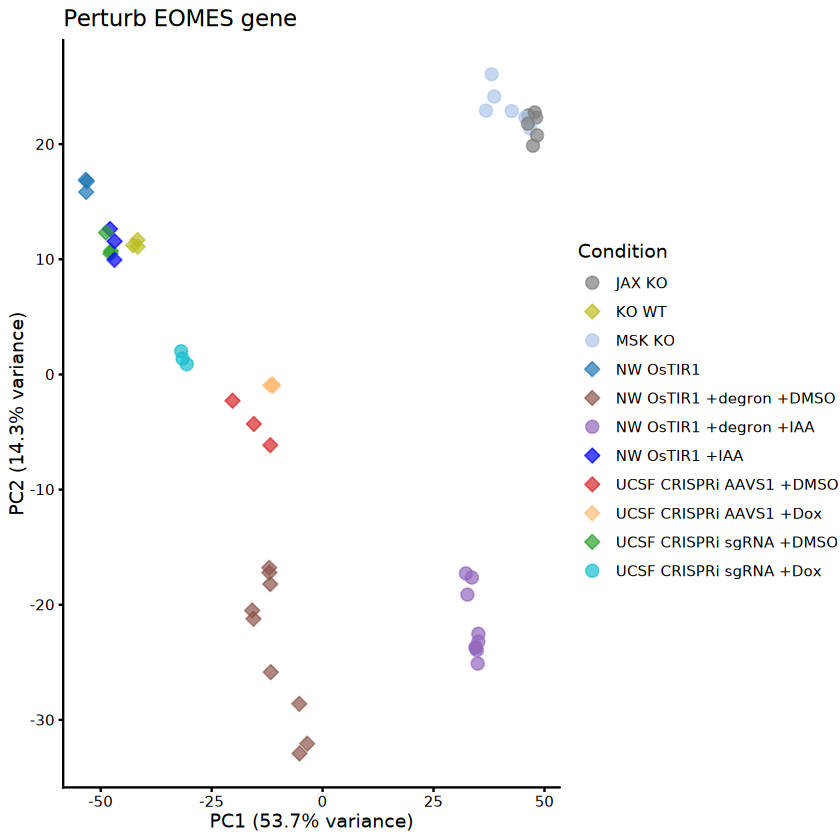

In [20]:

meta$read_depth = colSums(cts_dat)/1e6
meta$q75 = apply(cts_dat, 2, quantile, probs = 0.75)
meta$run_id_short = meta$run_id

# PCA of all samples
y_pca <- DGEList(counts = cts_dat)
y_pca <- calcNormFactors(y_pca, method = "TMM")
logCPM_pca <- cpm(y_pca, log = TRUE)

gene_vars <- apply(logCPM_pca, 1, var)
gene_means <- apply(logCPM_pca, 1, mean)
top_genes <- order(gene_vars, decreasing = TRUE)[1:2500]
logCPM_top <- logCPM_pca[top_genes, ]

mv_df <- data.frame(
  Gene = rownames(logCPM_pca),
  Mean = gene_means,
  Variance = gene_vars,
  Selected = rownames(logCPM_pca) %in% rownames(logCPM_top)
)

pca_input <- t(logCPM_top)
sample_pca <- prcomp(pca_input, center = TRUE, scale. = TRUE)
pc_scores = sample_pca$x
eigen_vals = sample_pca$sdev^2
pvs = round(eigen_vals[1:5]/sum(eigen_vals)*100, 1)

PC_df = data.frame(pc_scores)
PC_df = cbind(PC_df, meta)

# 1. Define the specific name mappings
label_map <- c(
  "UCSF"      = "UCSF CRISPRi AAVS1 +DMSO",
  "UCSF_DOX"  = "UCSF CRISPRi AAVS1 +Dox",
  "UCSF_KO_9" = "UCSF CRISPRi sgRNA +DMSO",
  "KO_9_DOX"  = "UCSF CRISPRi sgRNA +Dox",
  
  "NWU"       = "NW OsTIR1",
  "NWU_IAA"   = "NW OsTIR1 +IAA",
  "NWU_KO_2"  = "NW OsTIR1 +degron +DMSO",
  "KO_2_IAA"  = "NW OsTIR1 +degron +IAA",
  "NWU_KO_45" = "NW OsTIR1 +degron +DMSO",
  "KO_45_IAA" = "NW OsTIR1 +degron +IAA",
  "NWU_46_KO" = "NW OsTIR1 +degron +DMSO",
  "KO_46_IAA" = "NW OsTIR1 +degron +IAA",
  
  "JAX_KO_10" = "JAX KO",
  "JAX_KO_12" = "JAX KO",
  
  "MSK_KO_2"  = "MSK KO",
  "MSK_KO_9"  = "MSK KO",
  "KOLF"        = "KO WT"
)

PC_df$plot_label <- label_map[PC_df$Dcondition]
is_na_label <- is.na(PC_df$plot_label)
PC_df$plot_label[is_na_label] <- gsub("_", " ", PC_df$ko_strategy_clean[is_na_label])
my_colors <- c("blue", paletteer::paletteer_d("ggsci::category20_d3")[1:12])
names(my_colors) = c("NW OsTIR1 +IAA", "NW OsTIR1", "UCSF CRISPRi WT", "UCSF CRISPRi sgRNA +DMSO", "UCSF CRISPRi AAVS1 +DMSO", "NW OsTIR1 +degron +IAA",
                     "NW OsTIR1 +degron +DMSO", "NW WT", "JAX KO", "KO WT", "UCSF CRISPRi sgRNA +Dox", "MSK KO", "UCSF CRISPRi AAVS1 +Dox")

shape_lookup <- ifelse(PC_df$ko_gene == "KO", 21, 23)
my_shapes <- setNames(shape_lookup, PC_df$plot_label)
my_shapes <- my_shapes[!duplicated(names(my_shapes))] # Ensure the list of shapes is unique

# 5. Build the plot
# Map color, fill, AND shape all to `plot_label` to force a single, merged legend
gPC = ggplot(PC_df, aes(x = PC1, y = PC2, color = plot_label, fill = plot_label, shape = plot_label)) +
  geom_point(size = 3, alpha = 0.7, stroke = 0.5) + 
  scale_color_manual(values = my_colors) +
  scale_fill_manual(values = my_colors) +
  scale_shape_manual(values = my_shapes) +
  labs(
    title = "Perturb EOMES gene",
    x = sprintf("PC1 (%.1f%% variance)", pvs[1]),
    y = sprintf("PC2 (%.1f%% variance)", pvs[2]),
    # Use the same title for all aesthetics to keep the legend merged
    color = "Condition",
    fill  = "Condition",
    shape = "Condition"
  ) +
  theme_classic() + # Optional: Use to recreate the exact background from your image
  theme(
    legend.margin = margin(0, 0, 0, 0), 
    legend.box.just = "left", 
    legend.direction = "vertical" 
  )

print(gPC)

# Save the plot
width_px  = 1600
height_px = round(width_px * (3/5))

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "EOMES_PCPlot_all_samples.png",sep='')),
  plot     = gPC,
  device   = ragg::agg_png,
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300
)


In [21]:
library(ggplot2)
library(dplyr)
library(tidyr)

# 1. Calculate total read depth in millions for each sample
total_depth_M <- colSums(cts_dat) / 1e6

# 2. Function to calculate percentiles per sample
# Note: It is usually best to filter out zeros in RNA-seq before calculating percentiles
calc_percentiles <- function(x) {
  quantile(x[x > 0], probs = c(0.75, 0.95)) 
}

# Apply across columns (samples) and transpose
sample_percentiles <- t(apply(cts_dat, 2, calc_percentiles))
colnames(sample_percentiles) <- c("P75", "P95")

# 3. Create a plotting dataframe
# Assuming you have a metadata table 'meta_dat' with a 'Group' column used for your PCA colors
qc_df <- data.frame(
  Sample = colnames(cts_dat),
  Total_Depth = total_depth_M,
  Group = PC_df$plot_label,
  ko_gene = PC_df$ko_gene
)
qc_df <- cbind(qc_df, sample_percentiles)

# 4. Pivot to long format so we can facet the plots by percentile
qc_long <- qc_df %>%
  pivot_longer(cols = starts_with("P"), 
               names_to = "Percentile", 
               values_to = "Expression_Count")

my_colors <- c("blue", paletteer::paletteer_d("ggsci::category20_d3")[1:12])
names(my_colors) = c("NW OsTIR +IAA", "NW OsTIR", "UCSF CRISPRi WT", "UCSF CRISPRi sgRNA +DMSO", "UCSF CRISPRi AAVS1 +DMSO", "NW OsTIR Gene Tag +IAA",
                     "NW OsTIR Gene Tag +DMSO", "NW WT", "JAX KO", "KO WT", "UCSF CRISPRi sgRNA +Dox", "MSK KO", "UCSF CRISPRi AAVS1 +Dox")

shape_lookup <- ifelse(qc_long$ko_gene == "KO", 21, 23)
my_shapes <- setNames(shape_lookup, qc_long$Group)
my_shapes <- my_shapes[!duplicated(names(my_shapes))]

# 5. Generate the faceted scatter plot
gPC = ggplot(qc_long, aes(x = Total_Depth, y = Expression_Count, color = Group, shape = Group)) +
  geom_point(size = 2, alpha = 0.8) +
  facet_wrap(~ Percentile, scales = "free_y") + # free_y allows each percentile to have its own y-axis scale
  theme_minimal() + scale_color_manual(values = my_colors) + scale_shape_manual(values = my_shapes) + 
  labs(
    title = "Expression Percentiles vs. Total Read Depth for EOMES",
    x = "Total Read Depth (Millions)",
    y = "Expression Count at Percentile",
    color = "Condition",
    shape = "Condition"
  )

# Save the plot
width_px  = 1800
height_px = round(width_px * (1/2))

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "EOMES_Check_Read_Depth.png",sep='')),
  plot     = gPC,
  device   = ragg::agg_png,
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300
)



### DE analysis for UCSF and NW



In [22]:
model1 = c("KO_2_IAA", "KO_45_IAA", "KO_46_IAA", "NWU_KO_2", "NWU_KO_45", "NWU_46_KO", "UCSF_KO_9", "KO_9_DOX")
sample2kp = which(meta$Dcondition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]
  
## Generate sample information matrix
sample_info = meta_m
model1 = c("UCSF_KO_9", "KO_9_DOX")
sample2kp = which(meta_m$Dcondition %in% model1)
cts_dat_m_UCSF = cts_dat_m[,sample2kp]
sample_info_UCSF = sample_info[sample2kp,]

library(edgeR)
library(limma)

# ---- inputs ----
counts  <- cts_dat_m_UCSF
colData <- sample_info_UCSF
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$ko_gene == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)
fitUCSF <- lmFit(v2, design2)

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitUCSF <- eBayes(contrasts.fit(fitUCSF, L2))
ttUCSF   <- topTable(fitUCSF, coef = "KOvsWT", number = Inf)
ttUCSF_before_max_mean_filter <- add_qvalue_and_cpm(ttUCSF, counts, group = group, apply_cpm_filter = FALSE)
ttUCSF <- filter_by_max_mean_cpm(ttUCSF_before_max_mean_filter, min_cpm = 1)


model1 = c("KO_2_IAA", "KO_45_IAA", "KO_46_IAA", "NWU_KO_2", "NWU_KO_45", "NWU_46_KO")
sample2kp = which(meta_m$Dcondition %in% model1)
cts_dat_m_NW = cts_dat_m[,sample2kp]
sample_info_NW = sample_info[sample2kp,]

library(edgeR)
library(limma)

# ---- inputs ----
counts  <- cts_dat_m_NW
colData <- sample_info_NW
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group-only model with optional clone duplicate-correlation block ----
group <- ifelse(colData$ko_gene == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT", "KO"))
clone_map <- c(
  "NWU_KO_2" = "2", "KO_2_IAA" = "2",
  "NWU_KO_45" = "45", "KO_45_IAA" = "45",
  "NWU_46_KO" = "46", "KO_46_IAA" = "46"
)
clone <- factor(unname(clone_map[as.character(colData$Dcondition)]))
stopifnot(!anyNA(clone), all(table(clone, group) > 0))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT", "KO")

# ---- normalization + voom ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)
fitNW <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = clone, fit_label = "fitNW")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitNW <- eBayes(contrasts.fit(fitNW, L2))
ttNW   <- topTable(fitNW, coef = "KOvsWT", number = Inf)
ttNW_before_max_mean_filter <- add_qvalue_and_cpm(ttNW, counts, group = group, apply_cpm_filter = FALSE)
ttNW <- filter_by_max_mean_cpm(ttNW_before_max_mean_filter, min_cpm = 1)

# pheatmap(cor(v2$E))


Estimated duplicate-correlation for fitNW: 0.306




### DE analysis for NW parents



In [23]:
model1 = c("KO_2_IAA", "KO_45_IAA", "KO_46_IAA", "NWU_IAA", "UCSF_KO_9", "KO_9_DOX")
sample2kp = which(meta$Dcondition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]
  
## Generate sample information matrix
sample_info = meta_m

model1 = c("KO_2_IAA", "KO_45_IAA", "KO_46_IAA", "NWU_IAA")
sample2kp = which(meta_m$Dcondition %in% model1)
cts_dat_m_NW = cts_dat_m[,sample2kp]
sample_info_NW = sample_info[sample2kp,]

library(edgeR)
library(limma)

# ---- inputs ----
counts  <- cts_dat_m_NW
colData <- sample_info_NW
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$ko_gene == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- clone/block vector for optional duplicate-correlation ----
block <- as.character(colData$Dcondition)
block[group == "WT"] <- paste0("WT_", seq_len(sum(group == "WT")))

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)
fitNW <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = block, fit_label = "fitNW_parent")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitNW <- eBayes(contrasts.fit(fitNW, L2))
ttNW_parent   <- topTable(fitNW, coef = "KOvsWT", number = Inf)
ttNW_parent_before_max_mean_filter <- add_qvalue_and_cpm(ttNW_parent, counts, group = group, apply_cpm_filter = FALSE)
ttNW_parent <- filter_by_max_mean_cpm(ttNW_parent_before_max_mean_filter, min_cpm = 1)

# pheatmap(cor(v2$E))


Estimated duplicate-correlation for fitNW_parent: 0.449




### DE analysis for JAX and MSK



In [24]:
model1 = c("JAX_KO_10", "JAX_KO_12", "MSK_KO_9", "MSK_KO_2", "KOLF")
sample2kp = which(meta$Dcondition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]
  
## Generate sample information matrix
sample_info = meta_m

model1 = c("JAX_KO_10", "JAX_KO_12", "KOLF")
sample2kp = which(meta_m$Dcondition %in% model1)
cts_dat_m_JAX = cts_dat_m[,sample2kp]
sample_info_JAX = sample_info[sample2kp,]

library(edgeR)
library(limma)

# ---- inputs ----
counts  <- cts_dat_m_JAX
colData <- sample_info_JAX
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$ko_gene == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- block vector: KO keep clone IDs; WT each unique ----
isWT  <- group == "WT"
block <- as.character(colData$Dcondition)
block[isWT] <- paste0("WT_", seq_len(sum(isWT)))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)

# ---- optional duplicate-correlation fit ----
fitJAX <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = block, fit_label = "fitJAX")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitJAX <- eBayes(contrasts.fit(fitJAX, L2))
ttJAX   <- topTable(fitJAX, coef = "KOvsWT", number = Inf)
ttJAX_before_max_mean_filter <- add_qvalue_and_cpm(ttJAX, counts, group = group, apply_cpm_filter = FALSE)
ttJAX <- filter_by_max_mean_cpm(ttJAX_before_max_mean_filter, min_cpm = 1)




model1 = c("MSK_KO_9", "MSK_KO_2", "KOLF")
sample2kp = which(meta$Dcondition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]
  
## Generate sample information matrix
sample_info = meta_m

sample2kp = which(meta_m$Dcondition %in% model1)
cts_dat_m_MSK = cts_dat_m[,sample2kp]
sample_info_MSK = sample_info[sample2kp,]

library(edgeR)
library(limma)

# ---- inputs ----
counts  <- cts_dat_m_MSK
colData <- sample_info_MSK
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$ko_gene == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- block vector: KO keep clone IDs; WT each unique ----
isWT  <- group == "WT"
block <- as.character(colData$Dcondition)
block[isWT] <- paste0("WT_", seq_len(sum(isWT)))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)

# ---- optional duplicate-correlation fit ----
fitMSK <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = block, fit_label = "fitMSK")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitMSK <- eBayes(contrasts.fit(fitMSK, L2))
ttMSK   <- topTable(fitMSK, coef = "KOvsWT", number = Inf)
ttMSK_before_max_mean_filter <- add_qvalue_and_cpm(ttMSK, counts, group = group, apply_cpm_filter = FALSE)
ttMSK <- filter_by_max_mean_cpm(ttMSK_before_max_mean_filter, min_cpm = 1)



Estimated duplicate-correlation for fitJAX: 0.033

Estimated duplicate-correlation for fitMSK: 0.265




### Volcano plot visualization



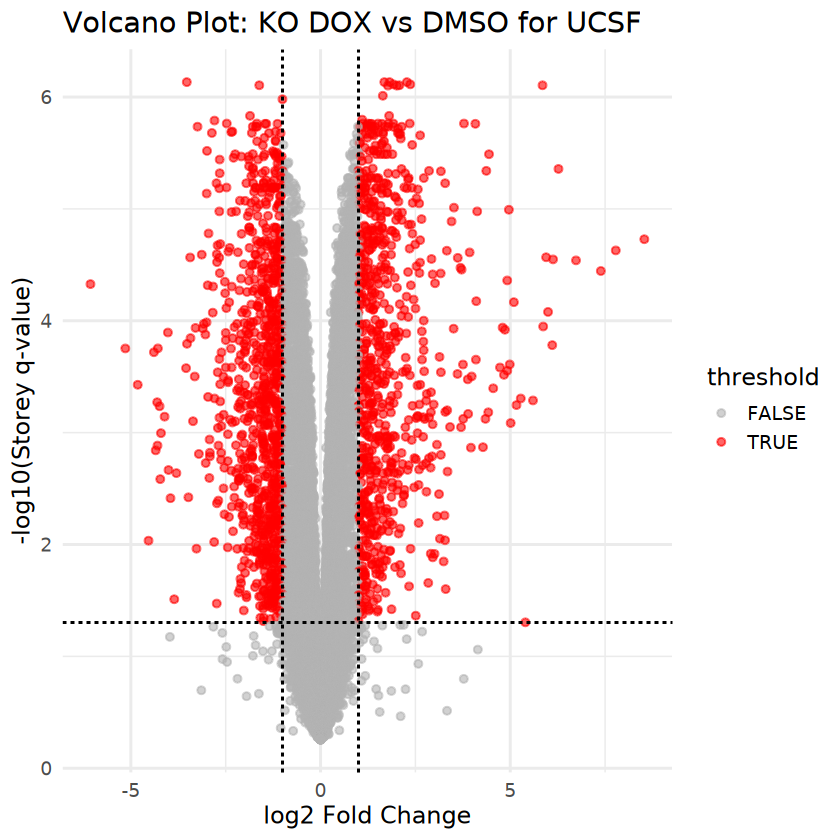

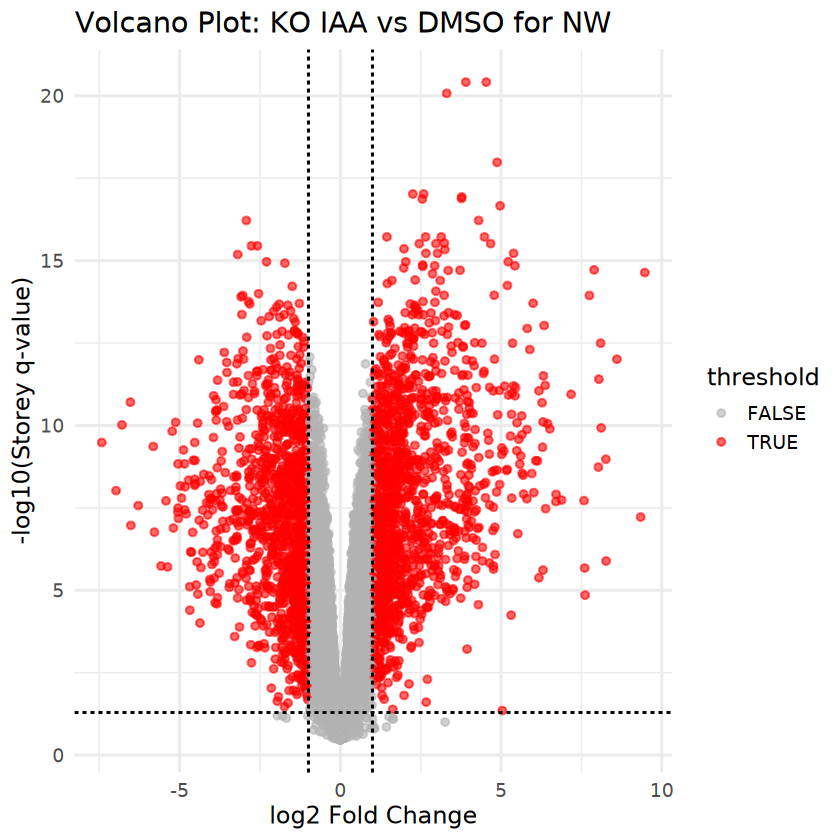

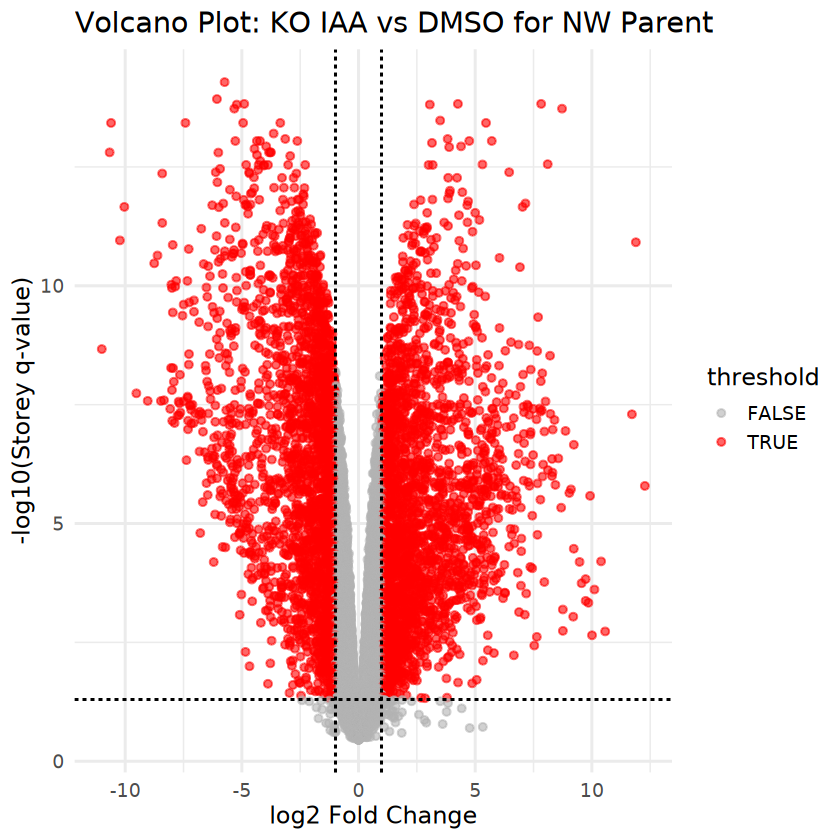

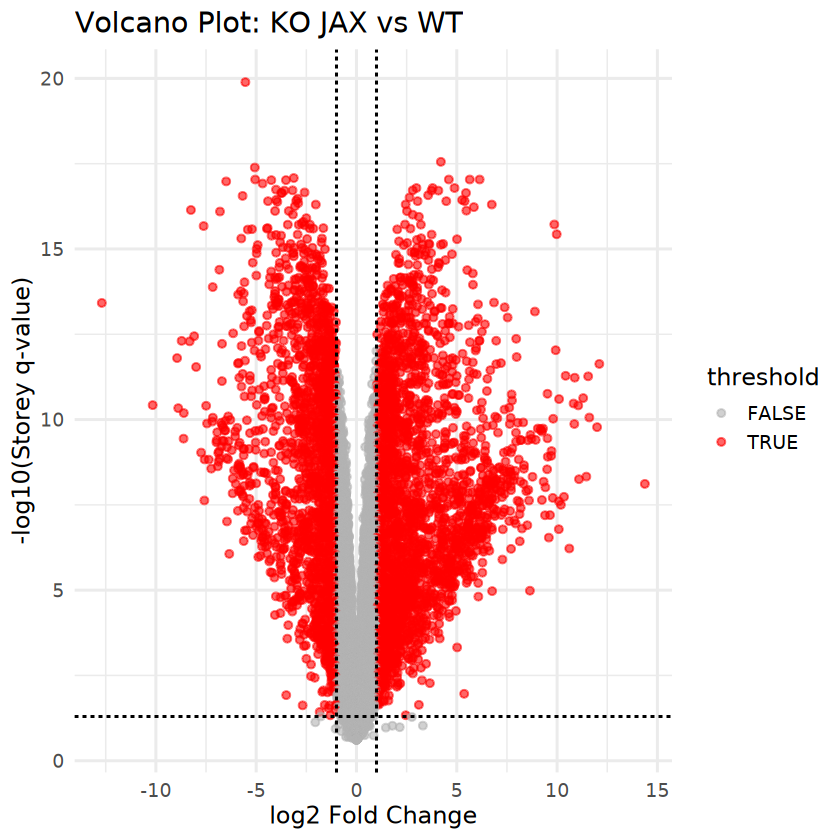

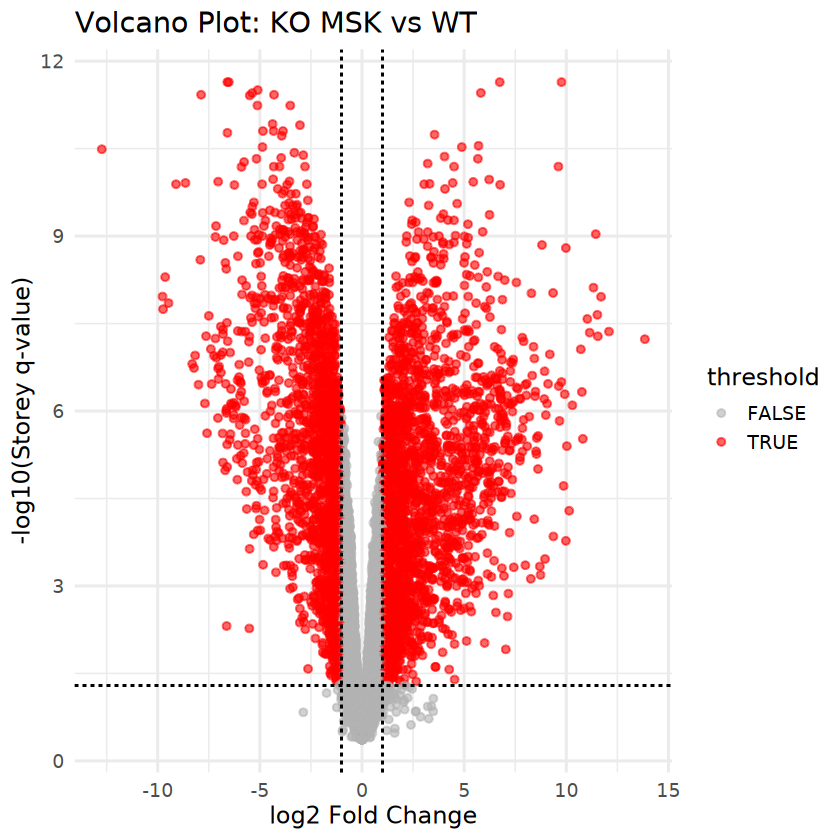

In [25]:
# Add a significance column for coloring
ttUCSF$threshold <- ttUCSF$q75_pass &
  !is.na(ttUCSF$qvalue) & ttUCSF$qvalue < 0.05 &
  is.finite(ttUCSF$logFC) & abs(ttUCSF$logFC) > 1 &
  is.finite(ttUCSF$max_mean_CPM) & ttUCSF$max_mean_CPM >= 1

p1 = ggplot(ttUCSF, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO DOX vs DMSO for UCSF",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")

# Add a significance column for coloring
ttNW$threshold <- ttNW$q75_pass &
  !is.na(ttNW$qvalue) & ttNW$qvalue < 0.05 &
  is.finite(ttNW$logFC) & abs(ttNW$logFC) > 1 &
  is.finite(ttNW$max_mean_CPM) & ttNW$max_mean_CPM >= 1

p2 = ggplot(ttNW, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO IAA vs DMSO for NW",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")

ttNW_parent$threshold <- ttNW_parent$q75_pass &
  !is.na(ttNW_parent$qvalue) & ttNW_parent$qvalue < 0.05 &
  is.finite(ttNW_parent$logFC) & abs(ttNW_parent$logFC) > 1 &
  is.finite(ttNW_parent$max_mean_CPM) & ttNW_parent$max_mean_CPM >= 1

pt = ggplot(ttNW_parent, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO IAA vs DMSO for NW Parent",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")


width_px  = 1920
height_px = round(width_px * (3/4)) 

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "EOMES_VolcanoPlot_UCSF.png",sep='')),
  plot     = p1,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)
ggsave(
  filename = file.path(personal_path, paste0("/publication/", "EOMES_VolcanoPlot_NW.png",sep='')),
  plot     = p2,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)
ggsave(
  filename = file.path(personal_path, paste0("/publication/", "EOMES_VolcanoPlot_NW_parent.png",sep='')),
  plot     = pt,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)

# Add a significance column for coloring
ttJAX$threshold <- ttJAX$q75_pass &
  !is.na(ttJAX$qvalue) & ttJAX$qvalue < 0.05 &
  is.finite(ttJAX$logFC) & abs(ttJAX$logFC) > 1 &
  is.finite(ttJAX$max_mean_CPM) & ttJAX$max_mean_CPM >= 1

p3 = ggplot(ttJAX, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO JAX vs WT",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")

# Add a significance column for coloring
ttMSK$threshold <- ttMSK$q75_pass &
  !is.na(ttMSK$qvalue) & ttMSK$qvalue < 0.05 &
  is.finite(ttMSK$logFC) & abs(ttMSK$logFC) > 1 &
  is.finite(ttMSK$max_mean_CPM) & ttMSK$max_mean_CPM >= 1

p4 = ggplot(ttMSK, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO MSK vs WT",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")

width_px  = 1920
height_px = round(width_px * (3/4))

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "EOMES_VolcanoPlot_JAX.png",sep='')),
  plot     = p3,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)
ggsave(
  filename = file.path(personal_path, paste0("/publication/", "EOMES_VolcanoPlot_MSK.png",sep='')),
  plot     = p4,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)
p1
p2
pt
p3
p4


In [26]:

library(ggplot2)
library(ggpointdensity)
library(ragg)

# ---- Parameters ----
width_px  <- 1600
height_px <- 1400

# ---- Helper to build paired data and plots ----
make_pair_plots <- function(A, B, nameA, nameB, logFC_col = "logFC", qvalue_col = "qvalue", base_size = 15) {
  genes <- intersect(rownames(A), rownames(B))
  A2 <- A[genes, , drop = FALSE]
  B2 <- B[genes, , drop = FALSE]

  df <- data.frame(
    logFC_A = A2[, logFC_col],
    qvalue_A = A2[, qvalue_col],
    logFC_B = B2[, logFC_col],
    qvalue_B = B2[, qvalue_col]
  )

  df <- na.omit(df)
  eps <- .Machine$double.xmin
  df$qvalue_A <- pmax(df$qvalue_A, eps)
  df$qvalue_B <- pmax(df$qvalue_B, eps)

  p_qvalue <- ggplot(df, aes(-log10(qvalue_A), -log10(qvalue_B))) +
    geom_pointdensity() +
    scale_fill_gradient(trans = "log10") +
    ggtitle(sprintf("Scatter of -log10 Storey q-values: %s vs %s", nameA, nameB)) +
    xlab(nameA) + ylab(nameB) +
    theme_classic(base_size = base_size) +
    geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed")

  p_lfc <- ggplot(df, aes(logFC_A, logFC_B)) +
    geom_pointdensity() +
    scale_fill_gradient(trans = "log10") +
    ggtitle(sprintf("Scatter of logFC: %s vs %s", nameA, nameB)) +
    xlab(nameA) + ylab(nameB) +
    theme_classic(base_size = base_size) +
    geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed")

  list(p_qvalue = p_qvalue, p_lfc = p_lfc)
}

# ---- Run for all pairs and save ----
datasets <- list(JAX = ttJAX, UCSF = ttUCSF, NW = ttNW, MSK = ttMSK, NW_parent = ttNW_parent)
pairs <- combn(names(datasets), 2, simplify = FALSE)

for (ab in pairs) {
  nameA <- ab[1]; nameB <- ab[2]
  plots <- make_pair_plots(datasets[[nameA]], datasets[[nameB]], nameA, nameB)

  # Save p-value plot
  ggsave(
    filename = file.path(personal_path, paste0("publication/", sprintf("EOMES_qvalue_%s-%s.png", nameA, nameB))),
    plot     = plots$p_qvalue,
    device   = ragg::agg_png,
    bg       = "transparent",
    width    = width_px,
    height   = height_px,
    units    = "px",
    dpi      = 300
  )

  # Save logFC plot
  ggsave(
    filename = file.path(personal_path, paste0("publication/", sprintf("EOMES_logFC_%s-%s.png", nameA, nameB))),
    plot     = plots$p_lfc,
    device   = ragg::agg_png,
    bg       = "transparent",
    width    = width_px,
    height   = height_px,
    units    = "px",
    dpi      = 300
  )

  message(sprintf("Saved plots for %s vs %s", nameA, nameB))
}


Saved plots for JAX vs UCSF

Saved plots for JAX vs NW

Saved plots for JAX vs MSK

Saved plots for JAX vs NW_parent

Saved plots for UCSF vs NW

Saved plots for UCSF vs MSK

Saved plots for UCSF vs NW_parent

Saved plots for NW vs MSK

Saved plots for NW vs NW_parent

Saved plots for MSK vs NW_parent




### Limma outputs



In [27]:
# 1) Fill missing HGNC symbols with Ensembl IDs
gene_anno$hgnc_symbol[is.na(gene_anno$hgnc_symbol) | gene_anno$hgnc_symbol == ""] <-
  gene_anno$ensembl_gene_id[is.na(gene_anno$hgnc_symbol) | gene_anno$hgnc_symbol == ""]

# 2) Helper: add "-1", "-2", … only for true duplicates, keeping singletons intact
make_unique_dash <- function(x) {
  ord <- seq_along(x)
  idx_within <- ave(ord, x, FUN = seq_along)
  dup_group <- duplicated(x) | duplicated(x, fromLast = TRUE)
  x_out <- x
  x_out[dup_group] <- paste0(x[dup_group], "-", idx_within[dup_group])
  x_out
}

# 3) Apply across the annotation
gene_anno$hgnc_symbol_unique <- make_unique_dash(gene_anno$hgnc_symbol)

# 4) Map Ensembl IDs → unique HGNC names

make_unique_dash <- function(x) {
  x <- as.character(x)
  ord <- seq_along(x)
  idx_within <- ave(ord, x, FUN = seq_along)
  dup_group <- duplicated(x) | duplicated(x, fromLast = TRUE)
  x_out <- x
  x_out[dup_group] <- paste0(x[dup_group], "-", idx_within[dup_group])
  x_out
}

map_symbols <- function(ids, anno) {
  ids <- as.character(ids)
  symbol_col <- if ("hgnc_symbol_unique" %in% colnames(anno)) "hgnc_symbol_unique" else "hgnc_symbol"
  mapped <- anno[[symbol_col]][match(ids, anno$ensembl_gene_id)]
  missing <- is.na(mapped) | mapped == ""
  mapped[missing] <- ids[missing]
  make_unique_dash(mapped)
}

publication_dir <- file.path(personal_path, "publication")
before_max_mean_filter_dir <- file.path(publication_dir, "DE_before_max_mean_filter")
after_max_mean_filter_dir <- file.path(publication_dir, "DE_after_max_mean_filter")
dir.create(before_max_mean_filter_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(after_max_mean_filter_dir, recursive = TRUE, showWarnings = FALSE)

use_gene_symbols_as_rownames <- function(tt) {
  rownames(tt) <- map_symbols(rownames(tt), gene_anno)
  tt
}

write_de_table_pair <- function(before_filter, after_filter, file_name) {
  write.table(
    before_filter,
    file = file.path(before_max_mean_filter_dir, file_name),
    sep = "	",
    quote = FALSE
  )
  write.table(
    after_filter,
    file = file.path(after_max_mean_filter_dir, file_name),
    sep = "	",
    quote = FALSE
  )
  # Top-level DE CSVs keep all q75-passing genes; the after-filter copy is saved above.
  write.table(
    before_filter,
    file = file.path(publication_dir, file_name),
    sep = "	",
    quote = FALSE
  )
}

ttJAX_before_max_mean_filter <- use_gene_symbols_as_rownames(ttJAX_before_max_mean_filter)
ttJAX <- use_gene_symbols_as_rownames(ttJAX)
ttUCSF_before_max_mean_filter <- use_gene_symbols_as_rownames(ttUCSF_before_max_mean_filter)
ttUCSF <- use_gene_symbols_as_rownames(ttUCSF)
ttNW_before_max_mean_filter <- use_gene_symbols_as_rownames(ttNW_before_max_mean_filter)
ttNW <- use_gene_symbols_as_rownames(ttNW)
ttNW_parent_before_max_mean_filter <- use_gene_symbols_as_rownames(ttNW_parent_before_max_mean_filter)
ttNW_parent <- use_gene_symbols_as_rownames(ttNW_parent)
ttMSK_before_max_mean_filter <- use_gene_symbols_as_rownames(ttMSK_before_max_mean_filter)
ttMSK <- use_gene_symbols_as_rownames(ttMSK)

write_de_table_pair(ttJAX_before_max_mean_filter, ttJAX, "EOMES_DE_JAX.csv")
write_de_table_pair(ttUCSF_before_max_mean_filter, ttUCSF, "EOMES_DE_UCSF.csv")
write_de_table_pair(ttNW_before_max_mean_filter, ttNW, "EOMES_DE_NW.csv")
write_de_table_pair(ttNW_parent_before_max_mean_filter, ttNW_parent, "EOMES_DE_NW_parent.csv")
write_de_table_pair(ttMSK_before_max_mean_filter, ttMSK, "EOMES_DE_MSK.csv")


                 JAX       MSK        NW NW_parents      UCSF
JAX        1.0000000 0.9376175 0.5335872  0.5907859 0.2133180
MSK        0.8037815 1.0000000 0.5163827  0.5875475 0.1904795
NW         0.3462609 0.3550792 1.0000000  0.6392391 0.4149273
NW_parents 0.4211450 0.4050499 0.3889789  1.0000000 0.3478037
UCSF       0.2219190 0.1866182 0.2355569  0.2175092 1.0000000


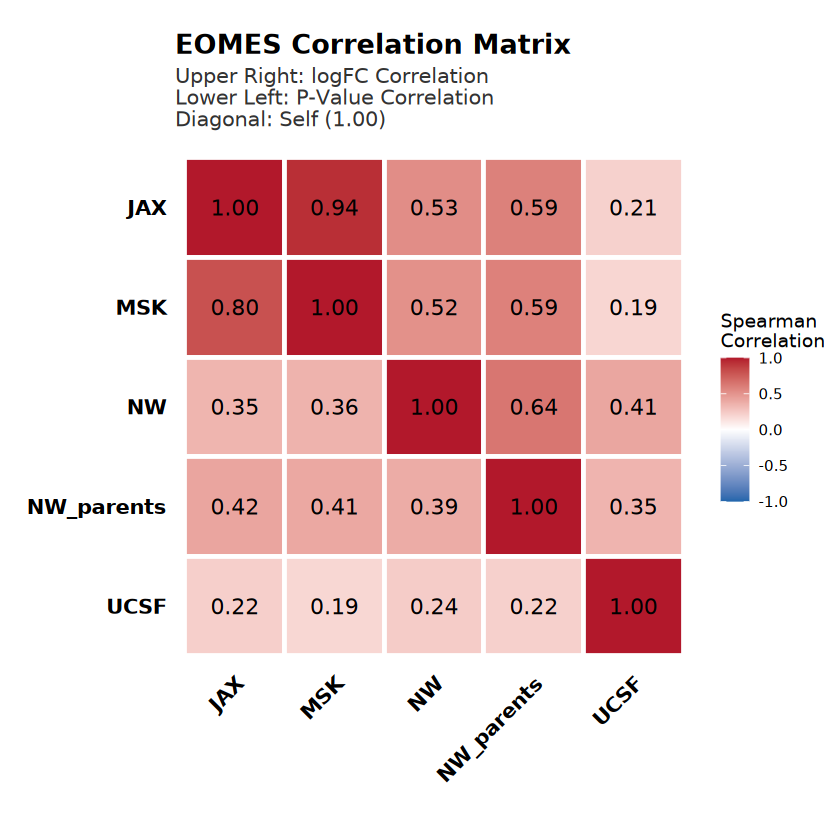

In [28]:
# 1. Put all your dataframes into a named list
# Make sure your 5 dataframes are named accordingly in your environment
df_list <- list(
  JAX = ttJAX,
  MSK = ttMSK,
  NW = ttNW,
  NW_parents = ttNW_parent,
  UCSF = ttUCSF
)

# 2. Find the common genes across all 5 datasets
# Assuming your gene names are the row names (as shown in your ttJAX snippet)
common_genes <- Reduce(intersect, lapply(df_list, rownames))

# Optional: If your gene names are actually in a column named 'V1', use this instead:
# common_genes <- Reduce(intersect, lapply(df_list, function(x) x$V1))

# 3. Extract the logFC and P.Value for these common genes
logFC_matrix <- sapply(df_list, function(df) df[common_genes, "logFC"])
pval_matrix  <- sapply(df_list, function(df) df[common_genes, "P.Value"])

# 4. Calculate the correlation matrices
# Note: "pearson" is standard, but you can change to "spearman" if you want rank-based correlation
cor_logFC <- cor(logFC_matrix, method = "spearman", use = "pairwise.complete.obs")
cor_pval  <- cor(pval_matrix, method = "spearman", use = "pairwise.complete.obs")

# 5. Initialize the combined matrix with 1s on the diagonal
n_datasets <- length(df_list)
combined_matrix <- matrix(1, nrow = n_datasets, ncol = n_datasets)
rownames(combined_matrix) <- names(df_list)
colnames(combined_matrix) <- names(df_list)

# 6. Fill the Upper Triangle with logFC correlations
combined_matrix[upper.tri(combined_matrix)] <- cor_logFC[upper.tri(cor_logFC)]

# 7. Fill the Lower Triangle with P.Value correlations
combined_matrix[lower.tri(combined_matrix)] <- cor_pval[lower.tri(cor_pval)]

# Print the final matrix
print(combined_matrix)

# --- Heatmap Visualization ---

# 1. Convert the matrix into a long-format dataframe suitable for ggplot
cor_df <- as.data.frame(as.table(combined_matrix))
colnames(cor_df) <- c("Dataset1", "Dataset2", "Correlation")

# 2. Reverse the factor order of Dataset1 so the diagonal goes from top-left to bottom-right
cor_df$Dataset1 <- factor(cor_df$Dataset1, levels = rev(rownames(combined_matrix)))
cor_df$Dataset2 <- factor(cor_df$Dataset2, levels = colnames(combined_matrix))

# 3. Create the Heatmap using ggplot2
plot_heatmap <- ggplot(data = cor_df, aes(x = Dataset2, y = Dataset1, fill = Correlation)) +
  geom_tile(color = "white", size = 1) +
  
  # Red/Blue color gradient (Standard for correlations: Red = +1, Blue = -1)
  scale_fill_gradient2(low = "#2166AC", mid = "white", high = "#B2182B", 
                       midpoint = 0, limit = c(-1, 1), name = "Spearman\nCorrelation") +
  
  # Add the correlation numbers inside the boxes (rounded to 2 decimal places)
  geom_text(aes(label = sprintf("%.2f", Correlation)), color = "black", size = 4.5) +
  
  # Clean minimal theme
  theme_minimal() +
  coord_fixed() + # Keeps the tiles perfectly square
  
  # Labels and Title (Explaining Upper vs Lower)
  labs(
    title = "EOMES Correlation Matrix",
    subtitle = "Upper Right: logFC Correlation\nLower Left: P-Value Correlation\nDiagonal: Self (1.00)",
    x = "",
    y = ""
  ) +
  
  # Theme adjustments for font sizes and angles
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 12, face = "bold", color="black"),
    axis.text.y = element_text(size = 12, face = "bold", color="black"),
    panel.grid.major = element_blank(), # Remove grid lines
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "gray20", margin = margin(b=10))
  )

# Display the plot
print(plot_heatmap)

# --- Optional: Save the plot ---
ggsave(
  filename = file.path(personal_path, paste0("publication/", "EOMES_Correlation_Heatmap.png")),
  plot     = plot_heatmap,
  device   = ragg::agg_png,
  bg       = "white",
  width    = 1800,
  height   = 1600,
  units    = "px",
  dpi      = 300
)
